# House Price Prediction

### Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

### Load the dataset

In [3]:
df = pd.read_csv("data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,5/2/2014 0:00,"313,000.00",3,1.50,1340,7912,1.50,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,5/2/2014 0:00,"2,384,000.00",5,2.50,3650,9050,2.00,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,5/2/2014 0:00,"342,000.00",3,2.00,1930,11947,1.00,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,5/2/2014 0:00,"420,000.00",3,2.25,2000,8030,1.00,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,5/2/2014 0:00,"550,000.00",4,2.50,1940,10500,1.00,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df.shape

(4600, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

### Remove rows where price is 0

In [7]:
print("rows with price == 0:", (df['price'] == 0).sum())
df = df[df['price'] != 0]
print("rows left:", len(df))

rows with price == 0: 49
rows left: 4551


### Remove price outliers using price-per-square-foot instead of raw price

In [8]:
df['price_per_sqft'] = df['price'] / df['sqft_living']

Q1 = np.log(df['price_per_sqft']).quantile(0.25)
Q3 = np.log(df['price_per_sqft']).quantile(0.75)
IQR = Q3 - Q1
lower = np.exp(Q1 - 3*IQR)
upper = np.exp(Q3 + 3*IQR)

print("removed as price/size outliers:", ((df['price_per_sqft'] < lower) | (df['price_per_sqft'] > upper)).sum())
df = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]
df = df.drop(columns=['price_per_sqft'])
print("rows left:", len(df))

removed as price/size outliers: 5
rows left: 4546


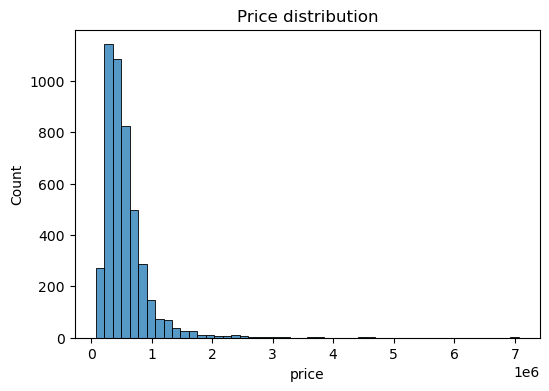

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=50)
plt.title("Price distribution")
plt.show()

### Feature engineering.

In [10]:
df['date'] = pd.to_datetime(df['date'])
current_year = df['date'].dt.year

df['house_age'] = current_year - df['yr_built']
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)
df['years_since_update'] = current_year - np.maximum(df['yr_built'], df['yr_renovated'])
df['has_basement'] = (df['sqft_basement'] > 0).astype(int)

df['bedrooms'] = df['bedrooms'].replace(0, np.nan)
df['bathrooms'] = df['bathrooms'].replace(0, np.nan)
df['sqft_per_bedroom'] = df['sqft_living'] / df['bedrooms']
df['bath_bed_ratio'] = df['bathrooms'] / df['bedrooms']
df['living_lot_ratio'] = df['sqft_living'] / df['sqft_lot']
df['log_sqft_lot'] = np.log1p(df['sqft_lot'])

df['quality_score'] = df['view'] + df['condition'] + df['waterfront']*3
df['zipcode'] = df['statezip'].str.split().str[1]

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,house_age,is_renovated,years_since_update,has_basement,sqft_per_bedroom,bath_bed_ratio,living_lot_ratio,log_sqft_lot,quality_score,zipcode
0,2014-05-02,"313,000.00",3.00,1.50,1340,7912,1.50,0,0,3,...,59,1,9,0,446.67,0.50,0.17,8.98,3,98133
1,2014-05-02,"2,384,000.00",5.00,2.50,3650,9050,2.00,0,4,5,...,93,0,93,1,730.00,0.50,0.40,9.11,9,98119
2,2014-05-02,"342,000.00",3.00,2.00,1930,11947,1.00,0,0,4,...,48,0,48,0,643.33,0.67,0.16,9.39,4,98042
3,2014-05-02,"420,000.00",3.00,2.25,2000,8030,1.00,0,0,4,...,51,0,51,1,666.67,0.75,0.25,8.99,4,98008
4,2014-05-02,"550,000.00",4.00,2.50,1940,10500,1.00,0,0,4,...,38,1,22,1,485.00,0.62,0.18,9.26,4,98052


### Correlation with price

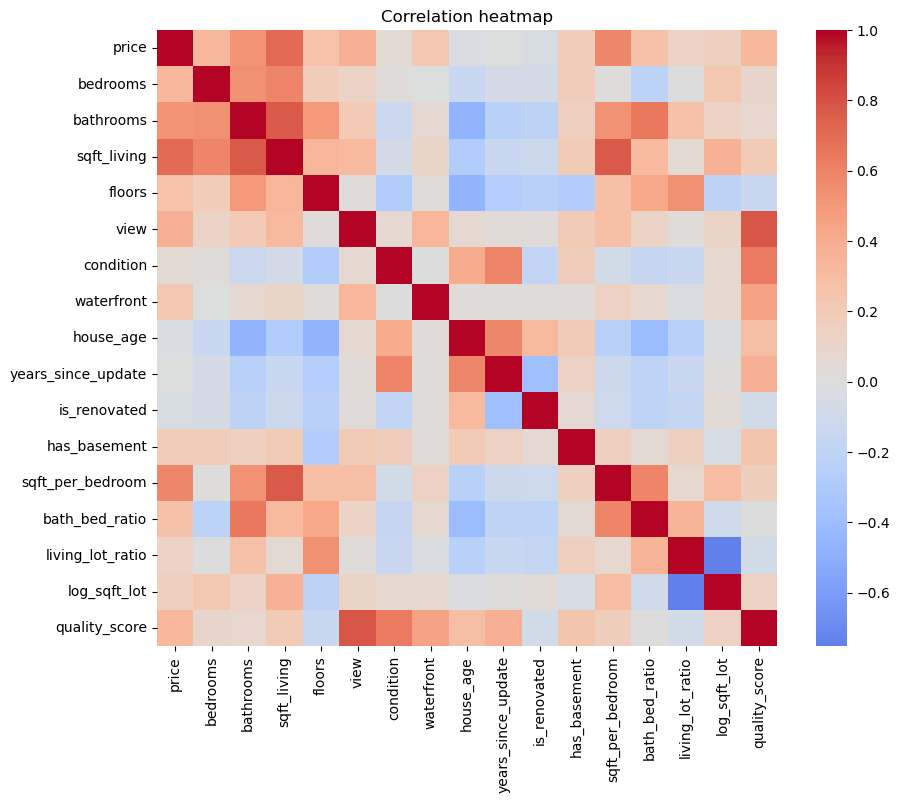

price                 1.00
sqft_living           0.70
sqft_per_bedroom      0.58
bathrooms             0.53
view                  0.38
bedrooms              0.34
quality_score         0.34
bath_bed_ratio        0.27
floors                0.26
waterfront            0.23
has_basement          0.18
log_sqft_lot          0.16
living_lot_ratio      0.13
condition             0.05
years_since_update   -0.00
house_age            -0.03
is_renovated         -0.04
Name: price, dtype: float64

In [11]:
num_cols = ['price','bedrooms','bathrooms','sqft_living','floors','view','condition','waterfront',
            'house_age','years_since_update','is_renovated','has_basement',
            'sqft_per_bedroom','bath_bed_ratio','living_lot_ratio','log_sqft_lot','quality_score']
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Correlation heatmap")
plt.show()

df[num_cols].corr()['price'].sort_values(ascending=False)

# Data Preprocessing

### Encode city and ZIP code

In [12]:
feature_cols = ['bedrooms','bathrooms','sqft_living','floors','view','condition','waterfront',
                 'house_age','years_since_update','is_renovated','has_basement',
                 'sqft_per_bedroom','bath_bed_ratio','living_lot_ratio','log_sqft_lot','quality_score',
                 'city','zipcode']

X = df[feature_cols].copy()
y = df['price']

# Split the dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((3636, 18), (910, 18))

In [14]:
log_y_train = np.log1p(y_train)
global_mean = log_y_train.mean()

for col in ['city', 'zipcode']:
    stats = log_y_train.groupby(X_train[col]).agg(['mean', 'count'])
    smoothed = (stats['mean'] * stats['count'] + global_mean * 10) / (stats['count'] + 10)
    X_train[col + '_enc'] = X_train[col].map(smoothed)
    X_test[col + '_enc'] = X_test[col].map(smoothed).fillna(global_mean)

X_train = X_train.drop(columns=['city', 'zipcode'])
X_test = X_test.drop(columns=['city', 'zipcode'])


X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

X_train.head()

,bedrooms,bathrooms,sqft_living,floors,view,condition,waterfront,house_age,years_since_update,is_renovated,has_basement,sqft_per_bedroom,bath_bed_ratio,living_lot_ratio,log_sqft_lot,quality_score,city_enc,zipcode_enc
540,3.00,2.50,1570,3.00,0,3,0,4,4,0,0,523.33,0.83,1.10,7.27,3,13.14,13.22
3946,5.00,2.50,3580,2.00,0,3,0,14,14,0,0,716.00,0.50,0.40,9.10,3,13.28,13.47
2097,3.00,3.00,2470,2.00,0,4,0,34,34,0,0,823.33,1.00,0.07,10.50,4,13.24,13.19
3279,4.00,2.50,2340,2.00,0,3,0,21,21,0,0,585.00,0.62,0.27,9.05,3,12.61,12.63
4332,4.00,2.25,1940,2.00,0,3,0,24,5,1,0,485.00,0.56,0.31,8.73,3,12.59,12.60


In [15]:
y_train_log = np.log1p(y_train)

# Linear Regression

In [16]:
model_LR = LinearRegression()
model_LR.fit(X_train, y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred_lr = np.expm1(model_LR.predict(X_test))  

In [18]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Mean Absolute Error:", mae_lr)
print("Mean Squared Error:", mse_lr)
print("Root Mean Squared Error:", rmse_lr)
print("R2-score:", r2_lr)

Mean Absolute Error: 102043.72052210635
Mean Squared Error: 103970002076.6853
Root Mean Squared Error: 322443.7967719108
R2-score: -0.0133682205016461
